In [2]:
#Fix relative paths
from pathlib import Path
import sys

p = Path.cwd().resolve()
repo_root = next(parent for parent in [p, *p.parents] if (parent / "src").exists())
sys.path.insert(0, str(repo_root / "src"))

In [3]:
#additional imports.
import numpy as np
from dataset import load_split
from dense_sift import extract_dense_sift
from classical_features import fit_codebook_from_descriptors, transform_with_codebook
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

In [4]:
#Load Dataset and Create Hyperparemeters
train_paths, test_paths, y_train, y_test, meta = load_split(repo_root /"splits")

train_paths = np.asarray(train_paths)
test_paths  = np.asarray(test_paths)
y_train = np.asarray(y_train)
y_test  = np.asarray(y_test)

CFG = dict(
    # Dense SIFT
    step=6,
    sizes=(16,),
    max_image_side=300,

    # Codebook / LLC / SPM
    K=1024,
    sample_size=100_000,
    batch_size=4096,
    levels=(1,2,4),
    knn=5,
    beta=1e-4,

    # SVM
    C=1.0,
    class_weight="balanced",

    seed=0,
)

print("Train:", len(train_paths), "Test:", len(test_paths), "Classes:", len(np.unique(y_train)))

Train: 6073 Test: 2604 Classes: 101


In [5]:
"""Dense-Sift Extraction"""
all_paths = np.concatenate([train_paths, test_paths])
all_paths = [str(p) for p in all_paths]

dsift_all = extract_dense_sift(
    all_paths,
    step=CFG["step"],
    sizes=CFG["sizes"],
    max_image_side=CFG["max_image_side"],
    show_progress=True,
)

dsift_train = dsift_all[:len(train_paths)]
dsift_test  = dsift_all[len(train_paths):]

print("Dense SIFT cached:",
      "train items:", len(dsift_train),
      "test items:", len(dsift_test))

Dense SIFT: 100%|██████████| 8677/8677 [20:06<00:00,  7.19it/s]

Dense SIFT cached: train items: 6073 test items: 2604


In [ ]:
"""Cross-Validation and model selection"""
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=CFG["seed"])

cv_scores = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(y_train)), y_train), start=1):
    #fold data
    ds_tr = [dsift_train[i] for i in tr_idx]
    ds_va = [dsift_train[i] for i in va_idx]
    y_tr = y_train[tr_idx]
    y_va = y_train[va_idx]

    # fit codebook on fold-train descriptors only
    desc_tr = [d for (d, _, _) in ds_tr]
    codebook = fit_codebook_from_descriptors(
        train_desc_list=desc_tr,
        K=CFG["K"],
        sample_size=CFG["sample_size"],
        batch_size=CFG["batch_size"],
        random_state=CFG["seed"] + fold,
    )

    #transform fold-train and fold-val using this codebook
    X_tr = transform_with_codebook(
        desc_xy_hw_list=ds_tr,
        codebook=codebook,
        levels=CFG["levels"],
        knn=CFG["knn"],
        beta=CFG["beta"],
        nonneg=True,
        l2_normalize=True,
        show_progress=False,
    )
    X_va = transform_with_codebook(
        desc_xy_hw_list=ds_va,
        codebook=codebook,
        levels=CFG["levels"],
        knn=CFG["knn"],
        beta=CFG["beta"],
        nonneg=True,
        l2_normalize=True,
        show_progress=False,
    )

    dual = True if X_tr.shape[0] < X_tr.shape[1] else False
    clf = LinearSVC(
        C=CFG["C"],
        class_weight=CFG["class_weight"],
        dual=dual,
        max_iter=5000,
        random_state=CFG["seed"] + fold,
    )
    clf.fit(X_tr, y_tr)

    acc = accuracy_score(y_va, clf.predict(X_va))
    cv_scores.append(acc)
    print(f"Fold {fold}: acc={acc:.4f}")

print("CV mean:", float(np.mean(cv_scores)), "CV std:", float(np.std(cv_scores)))

Fold 1: acc=0.7719
Fold 2: acc=0.7811
Fold 3: acc=0.7604
CV mean: 0.7711179427121456 CV std: 0.008487435584022582


In [7]:
"""Fit on all data"""
desc_train_full = [d for (d, _, _) in dsift_train]
codebook_final = fit_codebook_from_descriptors(
    train_desc_list=desc_train_full,
    K=CFG["K"],
    sample_size=CFG["sample_size"],
    batch_size=CFG["batch_size"],
    random_state=CFG["seed"],
)

# Transform full train and test
X_train = transform_with_codebook(
    desc_xy_hw_list=dsift_train,
    codebook=codebook_final,
    levels=CFG["levels"],
    knn=CFG["knn"],
    beta=CFG["beta"],
    nonneg=True,
    l2_normalize=True,
    show_progress=True,
)
X_test = transform_with_codebook(
    desc_xy_hw_list=dsift_test,
    codebook=codebook_final,
    levels=CFG["levels"],
    knn=CFG["knn"],
    beta=CFG["beta"],
    nonneg=True,
    l2_normalize=True,
    show_progress=True,
)

dual = True if X_train.shape[0] < X_train.shape[1] else False
final_clf = LinearSVC(
    C=CFG["C"],
    class_weight=CFG["class_weight"],
    dual=dual,
    max_iter=5000,
    random_state=CFG["seed"],
)
final_clf.fit(X_train, y_train)

test_acc = accuracy_score(y_test, final_clf.predict(X_test))
print("Final test accuracy:", float(test_acc))

LLC+SPM: 100%|██████████| 2604/2604 [06:18<00:00,  6.89it/s]


Final test accuracy: 0.793778801843318


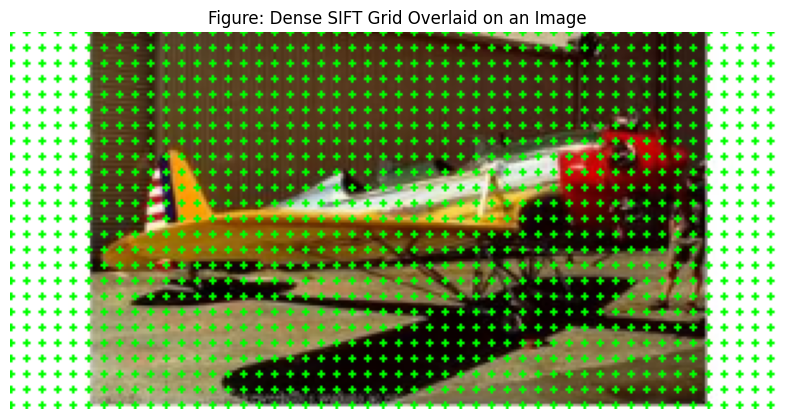

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

#Grab a sample image from your training paths
sample_path = train_paths[6]
img = cv2.imread(str(sample_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize it
h, w = img_rgb.shape[:2]
scale = 300 / float(max(h, w))
img_resized = cv2.resize(img_rgb, (int(w * scale), int(h * scale)))

# Draw the Dense Grid
vis_img = img_resized.copy()
step = 6
h_res, w_res = vis_img.shape[:2]

for y in range(0, h_res, step):
    for x in range(0, w_res, step):
        cv2.circle(vis_img, (x, y), 1, (0, 255, 0), -1)

#Save
plt.figure(figsize=(10, 6))
plt.imshow(vis_img)
plt.title(f"Figure: Dense SIFT Grid Overlaid on an Image")
plt.axis('off')
plt.savefig("dense_sift_visualization.png", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
y_pred_sift = final_clf.predict(X_test)
print("--- DENSE SIFT RESULTS ---")
print(classification_report(y_test, y_pred_sift, digits=3))

--- DENSE SIFT RESULTS ---
              precision    recall  f1-score   support

           0      0.955     0.969     0.962       131
           1      0.970     0.977     0.973       131
           2      0.882     1.000     0.938        60
           3      0.996     0.992     0.994       239
           4      0.941     1.000     0.970        16
           5      0.975     0.988     0.981       240
           6      0.833     0.385     0.526        13
           7      0.444     0.308     0.364        13
           8      0.750     0.429     0.545        14
           9      0.462     0.375     0.414        16
          10      0.556     0.357     0.435        14
          11      0.800     0.800     0.800        10
          12      0.763     0.763     0.763        38
          13      0.697     0.793     0.742        29
          14      0.500     0.385     0.435        13
          15      0.767     0.885     0.821        26
          16      0.769     0.741     0.755        27
